# Customer Churn — Model Training, Evaluation & Inference

This notebook covers:
1. Loading and exploring the raw dataset
2. Documenting data quality issues found (and how they were handled)
3. Training and comparing candidate models
4. Justifying the evaluation metric
5. Checking probability calibration
6. Final model training + held-out evaluation
7. A clean, callable `predict_churn_risk(customer_id)` inference function
8. What-if scoring and aggregate/segment queries (the building blocks Stage 3's agent will call as tools)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 1. Load the data

In [ ]:
raw = pd.read_csv('backend/dataset/customer_churn.csv')
print('shape:', raw.shape)
raw.head()


shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
raw.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**First red flag:** `TotalCharges` is typed as an object/string column, not numeric 

## 2. Exploratory Data Analysis & Data Quality Issues

### 2.1 Target distribution

Churn rate: 26.537%


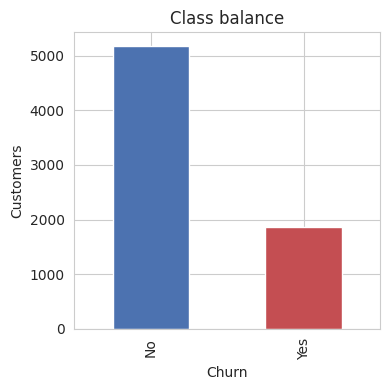

In [ ]:
churn_rate = (raw['Churn'] == 'Yes').mean()
print(f"Churn rate: {churn_rate}")

fig, ax = plt.subplots(figsize=(4,4))
raw['Churn'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_title('Class balance')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()


**Finding:** 26.5% churn, this is a mild-to-moderate imbalance. This means that oversampling techniques like SMOTE may not be too impactful if used

### 2.2 Missing values (naive check)

In [ ]:
raw.isna().sum()[raw.isna().sum() > 0]


Series([], dtype: int64)

`.isna()` reports **zero** missing values. But TotalCharges sometimes show empty cells when I saw, maybe they have empty strings

### 2.3 The real TotalCharges problem

In [ ]:
total_charges_numeric = pd.to_numeric(raw['TotalCharges'], errors='coerce')
bad_rows = raw[total_charges_numeric.isna()]
print(f"Rows where TotalCharges isn't a real number: {len(bad_rows)}")
bad_rows[['customerID','tenure','MonthlyCharges','TotalCharges','Contract','Churn']]


Rows where TotalCharges isn't a real number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Finding:** 11 rows have `TotalCharges = " "` (a blank space). Every one of these rows has:
- `tenure == 0`
- `Churn == 'No'`
- mostly one/two-year contracts

These are brand-new signups who haven't been billed yet, it's absent because no bill has been generated. 

We will not drop these rows because it will cause data loss of real customers. And also cant fill by mean because that would be misleading for new customers. A goog decision is **impute `0.0`**

### 2.4 Redundant categorical encodings

In [ ]:
noint_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for c in noint_cols:
    exact_match = ((raw[c] == 'No internet service') == (raw['InternetService'] == 'No')).all()
    print(f"{c:20s} 'No internet service' exactly matches InternetService=='No': {exact_match}")

phone_match = ((raw['MultipleLines'] == 'No phone service') == (raw['PhoneService'] == 'No')).all()
print(f"{'MultipleLines':20s} 'No phone service' exactly matches PhoneService=='No':   {phone_match}")


OnlineSecurity       'No internet service' exactly matches InternetService=='No': True
OnlineBackup         'No internet service' exactly matches InternetService=='No': True
DeviceProtection     'No internet service' exactly matches InternetService=='No': True
TechSupport          'No internet service' exactly matches InternetService=='No': True
StreamingTV          'No internet service' exactly matches InternetService=='No': True
StreamingMovies      'No internet service' exactly matches InternetService=='No': True
MultipleLines        'No phone service' exactly matches PhoneService=='No':   True


**Finding:** all six internet add-on columns carry a `"No internet service"` category that is **100% redundant** with `InternetService == 'No'` (1,526 rows). it's the same fact restated seven times. Same for `MultipleLines`'s `"No phone service"` vs `PhoneService`. 

If not fixed one-hot encoding would make 7 dummy columns encoding a single binary fact. 

**Decision: collapse `"No internet service"` and `"No phone service"` down to `"No"`** 

### 2.5 TotalCharges is a derived feature

In [ ]:
d = raw.copy()
d['TotalCharges'] = total_charges_numeric
d = d.dropna(subset=['TotalCharges'])

corr = np.corrcoef(d['tenure'], d['TotalCharges'])[0,1]
residual = (d['TotalCharges'] - d['tenure'] * d['MonthlyCharges']).abs()
print(f"corr(tenure, TotalCharges)          = {corr:.3f}")
print(f"median |TotalCharges - tenure*MonthlyCharges| = {residual.median():.2f}")
print(f"95th pct of that residual                     = {residual.quantile(0.95):.2f}")


corr(tenure, TotalCharges)          = 0.826
median |TotalCharges - tenure*MonthlyCharges| = 28.65
95th pct of that residual                     = 147.21


**Finding:** `TotalCharges` correlates 0.83 with `tenure` and is closely approximated by `tenure × MonthlyCharges`. This maybe a redundant column for linear classifiers but not for trees

### 2.6 Churn rate by key segments

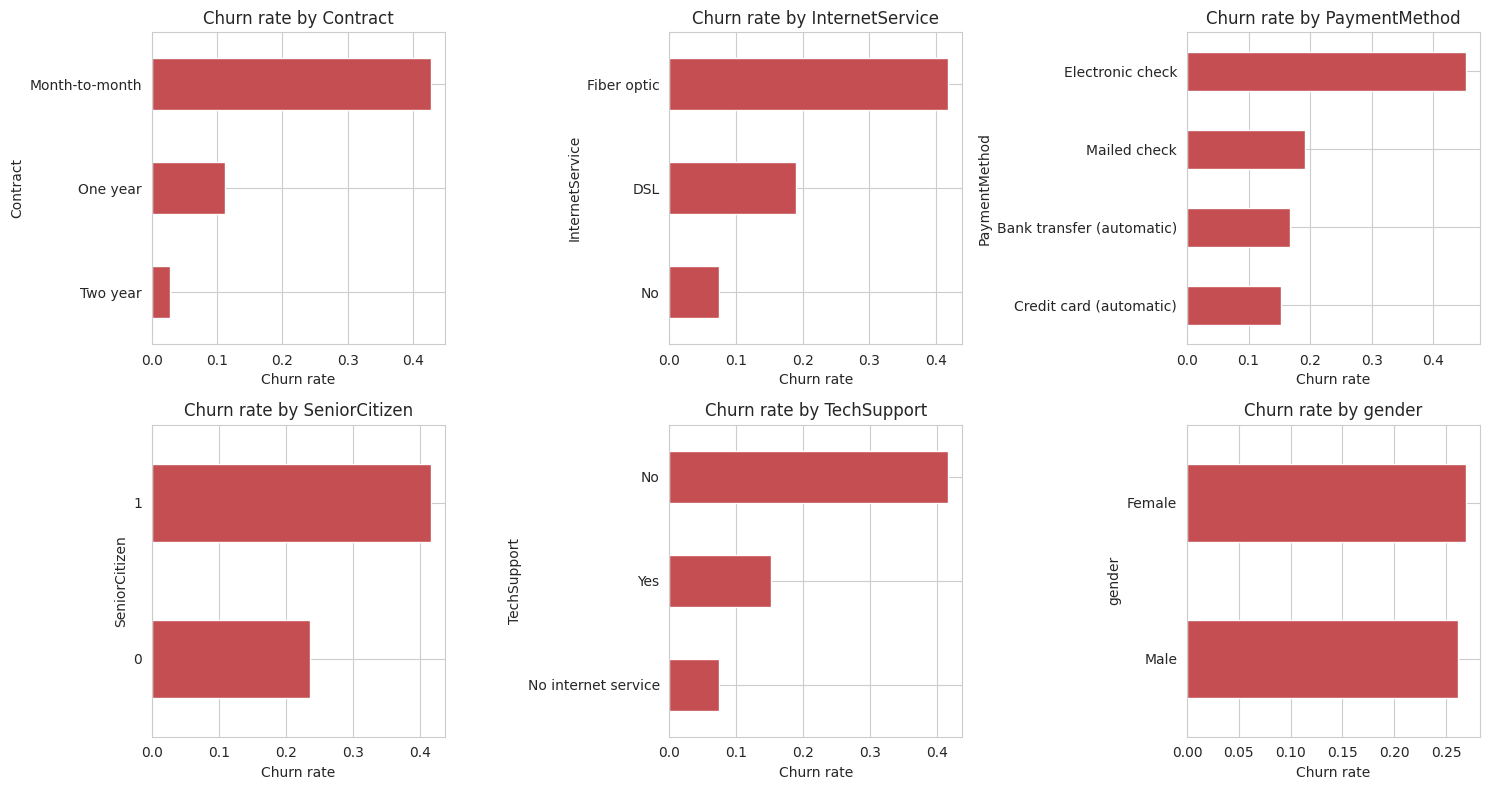

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
segment_cols = ['Contract','InternetService','PaymentMethod','SeniorCitizen','TechSupport','gender']
for ax, col in zip(axes.flat, segment_cols):
    rates = raw.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()).sort_values()
    rates.plot(kind='barh', ax=ax, color='#C44E52')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate')
plt.tight_layout()
plt.show()


**Findings:**
- **Contract** is the strongest single driver: month-to-month churns at ~43% vs. ~3% for two-year contracts.
- **Fiber optic** internet churns much more (~42%) than DSL (~19%) or no internet (~7%) — possibly price or service-quality related.
- **Electronic check** payers churn far more (~45%) than automatic payment methods (~15-17%) — friction-to-leave matters.
- **Senior citizens** churn more (~42% vs ~24%).

#### Noise
- **gender is essentially noise** — 26.9% vs 26.2%, no real difference. Kept in the model for completeness/transparency

## 3. Data Cleaning

Applying the decisions documented above, as one explicit, reproducible function — not ad-hoc edits scattered across cells.

In [ ]:
def clean_churn_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Apply the documented cleaning decisions from the EDA section.

    - TotalCharges: coerce to numeric; the 11 blank-string rows are all
      tenure==0 brand-new customers who haven't been billed -> impute 0.0.
    - Collapse the redundant 'No internet service' / 'No phone service'
      categories down to 'No' (they are 100% redundant with
      InternetService=='No' / PhoneService=='No').
    """
    df = df_raw.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)
    df = df.replace({'No internet service': 'No', 'No phone service': 'No'})
    return df

clean = clean_churn_data(raw)

assert clean['TotalCharges'].isna().sum() == 0, "cleaning left NaNs behind"
assert clean['customerID'].is_unique, "customerID should be unique"
print('Cleaned shape:', clean.shape)
clean.head()


Cleaned shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Train / Test Split

In [ ]:
TARGET = 'Churn'
CAT_COLS = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
            'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
NUM_COLS = ['tenure','MonthlyCharges','TotalCharges']
FEATURE_COLS = CAT_COLS + NUM_COLS

y = (clean[TARGET] == 'Yes').astype(int)
X = clean.drop(columns=[TARGET])   # customerID kept in X for lookup convenience, excluded from FEATURE_COLS

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train: {X_train.shape[0]} customers ({y_train.mean():.1%} churn)")
print(f"test:  {X_test.shape[0]} customers ({y_test.mean():.1%} churn)")


train: 5634 customers (26.5% churn)
test:  1409 customers (26.5% churn)


## 5. Preprocessing Pipeline & Model Comparison

In [ ]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'LogReg (plain)':    LogisticRegression(max_iter=2000),
    'LogReg (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RandomForest':      RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                                 class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'HistGB':            HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06,
                                                          max_leaf_nodes=15, l2_regularization=1.0,
                                                          random_state=RANDOM_STATE),
}


In [ ]:
cv_results = []
oof_predictions = {}   # out-of-fold probabilities, reused for the calibration plot in Section 6

for name, estimator in candidates.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', estimator)])
    proba = cross_val_predict(pipe, X_train[FEATURE_COLS], y_train,
                               cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    oof_predictions[name] = proba
    cv_results.append({
        'model': name,
        'ROC_AUC': roc_auc_score(y_train, proba),
        'PR_AUC': average_precision_score(y_train, proba),
        'Brier': brier_score_loss(y_train, proba),
    })

cv_results_df = pd.DataFrame(cv_results).set_index('model').round(4)
cv_results_df


,ROC_AUC,PR_AUC,Brier
model,,,
LogReg (plain),0.8456,0.6584,0.1351
LogReg (balanced),0.8454,0.6568,0.1653
RandomForest,0.8442,0.6528,0.1492
HistGB,0.8390,0.6468,0.1382


I choose PR-AUC, not ROC-AUC

All four models land within ~0.02 of each other on every metric, this dataset's ceiling is real and roughly fixed regardless of model complexity

**Why PR-AUC over ROC-AUC as the primary metric**, even though ROC-AUC's raw numbers are bigger:

- ROC-AUC's baseline is **always 0.5**, no matter how imbalanced the classes are. It's designed to getting the easy, plentiful "will not churn" majority right. Since the majority class is not predictive class, its easy for the model to get the negatives right, but false positives are a problem. ROC-AUC will optimize for False Positive Rate, but since actual negative samples are in majority, having many FPs will still reult in low FPR
- PR-AUC's baseline **equals the churn rate itself** (0.265 here). It only rewards being right about the minority class, which is the one this whole exercise is about. It optimizes for Precision instead of Accuracy, that's why negative sample size doesnt affect our eval
- So the honest comparison isn't the raw numbers, it's the multiple over each metric's own floor: our best model is **~1.7x** better than guessing on ROC-AUC, but **~2.5x** better than guessing on PR-AUC. The metric that looks smaller is actually the one where the model is doing relatively more work.

**Why the plain logistic regression, not `class_weight='balanced'`:** balancing barely moves ROC-AUC/PR-AUC, but it roughly doubles the Brier score (0.135 → 0.165) — i.e. it makes the actual probability numbers meaningfully less trustworthy in exchange for no real ranking benefit. 

**Why not a tree ensemble:** RandomForest/HistGB don't beat the linear model on any of the three metrics here

**Chosen model: plain (unweighted) `LogisticRegression`.**


## 6. Calibration Check

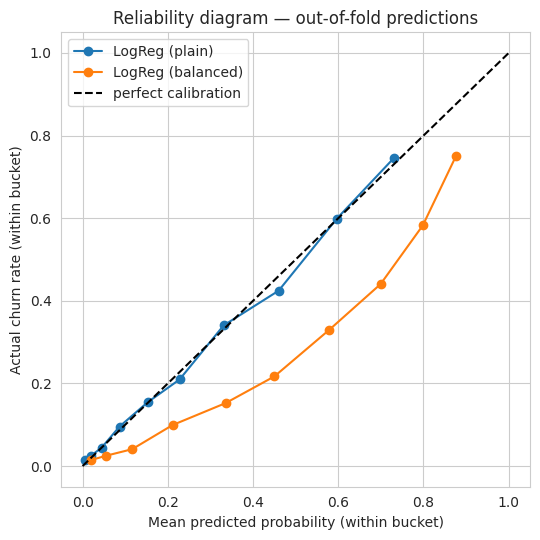

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,5.5))
for name in ['LogReg (plain)', 'LogReg (balanced)']:
    frac_pos, mean_pred = calibration_curve(y_train, oof_predictions[name], n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0,1], [0,1], 'k--', label='perfect calibration')
ax.set_xlabel('Mean predicted probability (within bucket)')
ax.set_ylabel('Actual churn rate (within bucket)')
ax.set_title('Reliability diagram — out-of-fold predictions')
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** the plain logistic regression is already pretty good calibrated that the balanced one, so we choose the plain one

## 7. Final Model — Train on Full Training Set

In [ ]:
final_model = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=2000)),
])
final_model.fit(X_train[FEATURE_COLS], y_train)
print('Final model fitted.')


Final model fitted.


## 8. Held-Out Test Set Evaluation

In [ ]:
test_proba = final_model.predict_proba(X_test[FEATURE_COLS])[:, 1]

print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, test_proba):.4f}")
print(f"Test Brier:   {brier_score_loss(y_test, test_proba):.4f}")


Test ROC-AUC: 0.8424
Test PR-AUC:  0.6359
Test Brier:   0.1379


              precision    recall  f1-score   support

    No churn       0.87      0.82      0.84      1035
       Churn       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



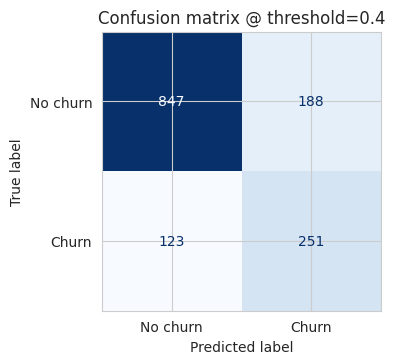

In [ ]:
THRESHOLD = 0.40  # see note below

test_pred = (test_proba >= THRESHOLD).astype(int)
print(classification_report(y_test, test_pred, target_names=['No churn','Churn']))

fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['No churn','Churn'],
                                         cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion matrix @ threshold={THRESHOLD}')
plt.tight_layout()
plt.show()


**On the threshold:** 0.40 is used here only so the notebook can report a concrete precision/recall/F1, it is *not* claimed to be cost-optimal. The mathematically correct threshold depends on the cost of a retention offer versus the lifetime value of a retained customer, and this dataset provides neither figure. 

## 9. Global Feature Importance

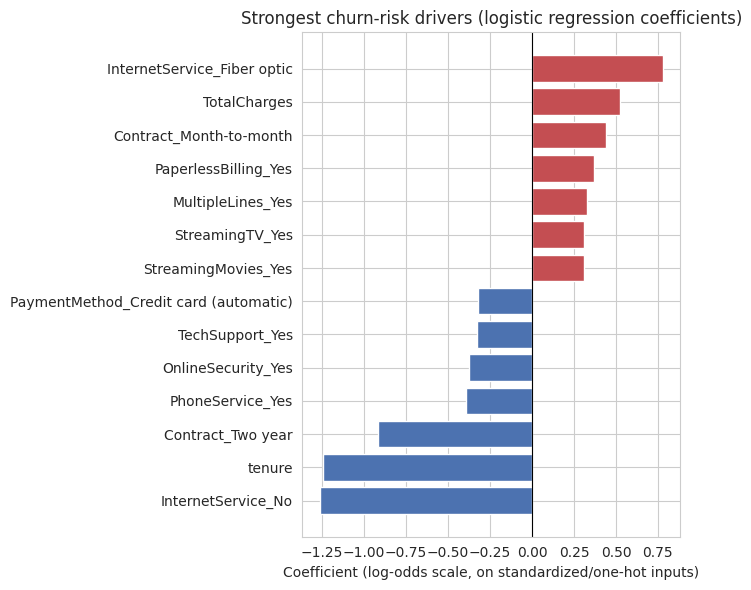

In [ ]:
ohe = final_model.named_steps['pre'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))
ALL_FEATURE_NAMES = cat_feature_names + NUM_COLS

coefs = final_model.named_steps['clf'].coef_[0]
assert len(coefs) == len(ALL_FEATURE_NAMES)

coef_df = pd.DataFrame({'feature': ALL_FEATURE_NAMES, 'coefficient': coefs}).sort_values('coefficient')
top_bottom = pd.concat([coef_df.head(7), coef_df.tail(7)])

fig, ax = plt.subplots(figsize=(7,6))
colors = ['#4C72B0' if c < 0 else '#C44E52' for c in top_bottom['coefficient']]
ax.barh(top_bottom['feature'], top_bottom['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Strongest churn-risk drivers (logistic regression coefficients)')
ax.set_xlabel('Coefficient (log-odds scale, on standardized/one-hot inputs)')
plt.tight_layout()
plt.show()


**Reading it:** longer contracts and having no internet service push risk down; fiber-optic internet, month-to-month contracts, and paperless billing push it up


## 10. Inference — `predict_churn_risk()`

In [ ]:
def predict_churn_risk(customer_id, df=clean, pipeline=final_model,
                        feature_cols=FEATURE_COLS, all_feature_names=ALL_FEATURE_NAMES, top_k=3):
    """Score a single existing customer by ID.

    Returns {'customer_id', 'risk_score', 'top_factors'} on success, or
    {'error': ...} if the ID isn't found -- callers should check for the
    'error' key rather than assume a well-formed result.
    """
    row = df.loc[df['customerID'] == customer_id]
    if row.empty:
        return {'error': f'customer_id {customer_id!r} not found'}

    x = row[feature_cols]
    risk_score = float(pipeline.predict_proba(x)[0, 1])

    pre_ = pipeline.named_steps['pre']
    clf_ = pipeline.named_steps['clf']
    x_transformed = pre_.transform(x)
    if hasattr(x_transformed, 'toarray'):
        x_transformed = x_transformed.toarray()
    contributions = x_transformed[0] * clf_.coef_[0]

    contrib_df = pd.DataFrame({'feature': all_feature_names, 'contribution': contributions})
    contrib_df['abs_contribution'] = contrib_df['contribution'].abs()
    top = contrib_df.sort_values('abs_contribution', ascending=False).head(top_k)

    top_factors = [
        {
            'feature': r.feature,
            'direction': 'increases_risk' if r.contribution > 0 else 'decreases_risk',
            'contribution': round(float(r.contribution), 4),
        }
        for r in top.itertuples()
    ]
    return {'customer_id': customer_id, 'risk_score': round(risk_score, 4), 'top_factors': top_factors}


In [ ]:
# demo: a real high-tenure, low-risk customer
sample_id = X_test.loc[X_test['tenure'] > 60, 'customerID'].iloc[0]
print(predict_churn_risk(sample_id))

# demo: error handling on a bad ID -- no stack trace, a clean error dict
print(predict_churn_risk('NOT-A-REAL-ID'))


{'customer_id': '4376-KFVRS', 'risk_score': 0.0453, 'top_factors': [{'feature': 'tenure', 'direction': 'decreases_risk', 'contribution': -2.0064}, {'feature': 'TotalCharges', 'direction': 'increases_risk', 'contribution': 1.4178}, {'feature': 'Contract_Two year', 'direction': 'decreases_risk', 'contribution': -0.9145}]}
{'error': "customer_id 'NOT-A-REAL-ID' not found"}


### 10.1 Scoring for Hypothetical customers

In [ ]:
def predict_for_new_customer(feature_dict, pipeline=final_model,
                              feature_cols=FEATURE_COLS, all_feature_names=ALL_FEATURE_NAMES, top_k=3):
    """Score a hypothetical customer described by a dict of feature values."""
    missing = [c for c in feature_cols if c not in feature_dict]
    if missing:
        return {'error': f'missing required fields: {missing}'}

    x = pd.DataFrame([feature_dict])[feature_cols]
    risk_score = float(pipeline.predict_proba(x)[0, 1])

    pre_ = pipeline.named_steps['pre']
    clf_ = pipeline.named_steps['clf']
    x_transformed = pre_.transform(x)
    if hasattr(x_transformed, 'toarray'):
        x_transformed = x_transformed.toarray()
    contributions = x_transformed[0] * clf_.coef_[0]

    contrib_df = pd.DataFrame({'feature': all_feature_names, 'contribution': contributions})
    contrib_df['abs_contribution'] = contrib_df['contribution'].abs()
    top = contrib_df.sort_values('abs_contribution', ascending=False).head(top_k)

    top_factors = [
        {
            'feature': r.feature,
            'direction': 'increases_risk' if r.contribution > 0 else 'decreases_risk',
            'contribution': round(float(r.contribution), 4),
        }
        for r in top.itertuples()
    ]
    return {'risk_score': round(risk_score, 4), 'top_factors': top_factors}


In [ ]:
# pick a real month-to-month customer so flipping the contract actually changes something
mtm_id = X_test.loc[X_test['Contract'] == 'Month-to-month', 'customerID'].iloc[0]
base_features = clean.loc[clean['customerID'] == mtm_id, FEATURE_COLS].iloc[0].to_dict()

whatif_features = dict(base_features)
whatif_features['Contract'] = 'Two year'

print('as-is (month-to-month):', predict_for_new_customer(base_features))
print('what-if (two-year):     ', predict_for_new_customer(whatif_features))


as-is (month-to-month): {'risk_score': 0.6849, 'top_factors': [{'feature': 'tenure', 'direction': 'increases_risk', 'contribution': 1.2433}, {'feature': 'InternetService_Fiber optic', 'direction': 'increases_risk', 'contribution': 0.7792}, {'feature': 'Contract_Month-to-month', 'direction': 'increases_risk', 'contribution': 0.4418}]}
what-if (two-year):      {'risk_score': 0.359, 'top_factors': [{'feature': 'tenure', 'direction': 'increases_risk', 'contribution': 1.2433}, {'feature': 'Contract_Two year', 'direction': 'decreases_risk', 'contribution': -0.9145}, {'feature': 'InternetService_Fiber optic', 'direction': 'increases_risk', 'contribution': 0.7792}]}


### 10.2 Aggregate / segment risk queries

In [ ]:
scored_test = X_test.copy()
scored_test['risk_score'] = test_proba
scored_test['actual_churn'] = y_test.values

def segment_risk(df_scored, **filters):
    """Average predicted risk (and, where labels are available, actual churn rate)
    for customers matching all given column=value filters."""
    mask = pd.Series(True, index=df_scored.index)
    for col, value in filters.items():
        mask &= (df_scored[col] == value)
    subset = df_scored[mask]
    if subset.empty:
        return {'error': 'no customers match this segment'}
    result = {'n_customers': int(len(subset)), 'avg_predicted_risk': round(float(subset['risk_score'].mean()), 4)}
    if 'actual_churn' in subset.columns:
        result['actual_churn_rate'] = round(float(subset['actual_churn'].mean()), 4)
    return result

print(segment_risk(scored_test, InternetService='Fiber optic'))
print(segment_risk(scored_test, Contract='Month-to-month', SeniorCitizen=1))


{'n_customers': 613, 'avg_predicted_risk': 0.4306, 'actual_churn_rate': 0.4111}
{'n_customers': 158, 'avg_predicted_risk': 0.5424, 'actual_churn_rate': 0.5696}


On held-out fiber-optic customers, average *predicted* risk and *actual* churn rate land within a couple of points of each other, that gap is the direct payoff of choosing the well-calibrated model

### 10.3 "Which customers are most likely to churn?"

In [ ]:
def top_n_at_risk(df_scored, n=10):
    """Return the n customers with the highest predicted risk score."""
    return (df_scored.sort_values('risk_score', ascending=False)
                      .head(n)[['customerID','risk_score','actual_churn']]
                      .reset_index(drop=True))

top_n_at_risk(scored_test, 10)


,customerID,risk_score,actual_churn
0,5178-LMXOP,0.854481,1
1,0295-PPHDO,0.832477,1
2,6861-XWTWQ,0.827008,1
3,8884-ADFVN,0.824702,1
4,9057-SIHCH,0.820062,1
5,6023-YEBUP,0.819283,1
6,1069-XAIEM,0.818959,1
7,1400-MMYXY,0.817724,1
8,2545-EBUPK,0.816183,0
9,8161-QYMTT,0.809992,0


## 11. Save Artifacts

The model must not be left stuck in the notebook, the agent backend will import it as a plain Python module. 

In [ ]:
joblib.dump(
    {
        'pipeline': final_model,
        'feature_cols': FEATURE_COLS,
        'all_feature_names': ALL_FEATURE_NAMES,
        'default_threshold': THRESHOLD,
    },
    'churn_model.joblib',
)
clean.to_csv('customer_churn_clean.csv', index=False)
print('Saved churn_model.joblib and customer_churn_clean.csv')


Saved churn_model.joblib and customer_churn_clean.csv


## 12. Summary

**Data issues found and handled:**
1. `TotalCharges` stored as string; 11 blank-string rows, all `tenure==0` brand-new signups -> changed to numeric, imputed as `0.0`.
2. Six add-on columns' `"No internet service"` category is 100% redundant with `InternetService=='No'` (same for `MultipleLines`/`PhoneService`) -> collapsed to `"No"`.
3. `TotalCharges ≈ tenure × MonthlyCharges` (corr 0.83), this is a derived column and can be redundant
4. `gender` carries no real signal (26.9% vs 26.2% churn). So it is kept for transparency, not predictive value.

**Metric choice:** PR-AUC (0.636 score) as the evaluation metric, because of the class imbalance, precision is more important and PR-AUC is more relevant to a problem that's fundamentally about finding a minority class. 

**Model choice:** plain (unweighted) logistic regression. It matched or beat RandomForest/HistGradientBoosting on both ranking metrics, had the lowest Brier score, and gives exact per-customer feature contributions for `top_factors` with no extra tooling.

**Threshold:** 0.40, used only to report a concrete confusion matrix in this notebook. This is not claimed as cost-optimal, since that depends upon the risk to reward of preventing a customer to churn based on business's own rules. The actual tool functions (`predict_churn_risk`, `predict_for_new_customer`) return continuous scores and leave any accept/reject decision to the user.
